In [1]:
import sys
import os

# Add the root path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.algorithms.solver import Solver
from src.visuals.state_visuals import plot_container_state
from src.utils.data_loader import load_container_from_json, load_warehouse_from_json

### 1. Load problem's data: 

In [2]:
data_path = "../src/data/3.json"

warehouse = load_warehouse_from_json(data_path)
container = load_container_from_json(data_path)

### 2. Create the solver using the required parameters:

In [3]:
params = {
    "n_pop": 20, 
    "n_gen": 10,
    "n_rep": 2,
    "cxpb": 0.7,
    "mutpb": 0.3,
    "n1": 1,          
    "n2": 1,           
    "s_depth": 1,      
    "s_width": 1
}

solver = Solver(**params)

### 3. Execute the solver, obtain the solution and plot it:

['gen', 'nevals', 'avg', 'std', 'min', 'max']
gen	nevals	avg     	std      	min   	max    
0  	20    	0.863437	0.0231567	0.7625	0.86875
1  	20    	0.86875 	0        	0.86875	0.86875
2  	20    	0.86875 	0        	0.86875	0.86875
3  	20    	0.86875 	0        	0.86875	0.86875
4  	20    	0.86875 	0        	0.86875	0.86875
5  	20    	0.86875 	0        	0.86875	0.86875
6  	20    	0.86875 	0        	0.86875	0.86875
7  	20    	0.86875 	0        	0.86875	0.86875
8  	20    	0.86875 	0        	0.86875	0.86875
9  	20    	0.86875 	0        	0.86875	0.86875


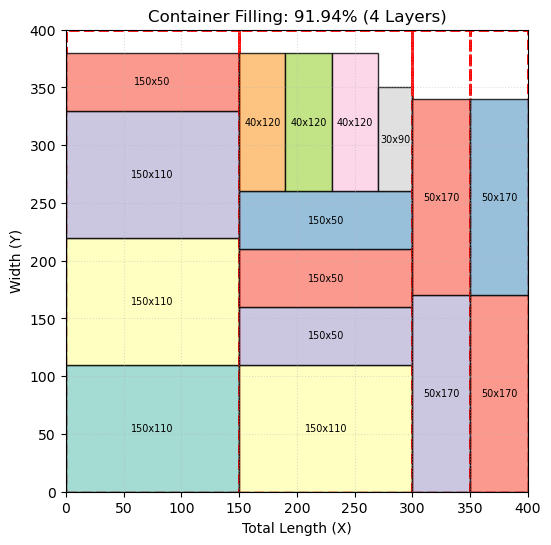

In [4]:
solution = solver.solve(container, warehouse)
plot_container_state(solution)

In [5]:
results_log = solver.get_log()

<Axes: title={'center': 'Evolución del Fitness (Baseline)'}, xlabel='generacion'>

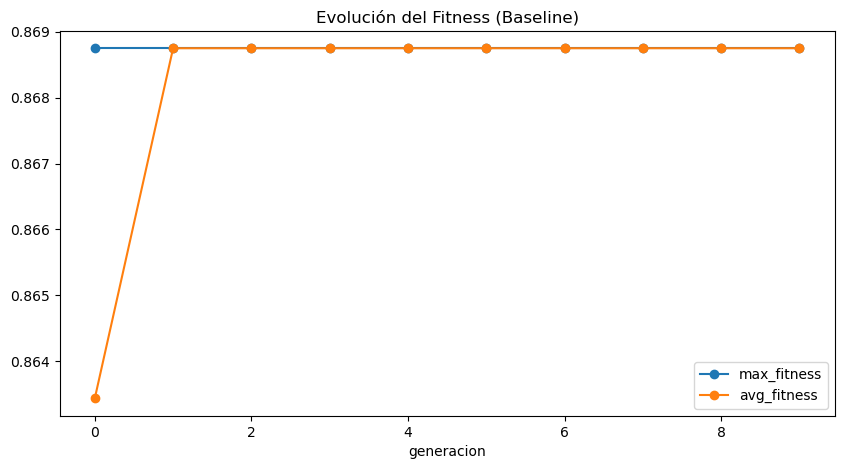

In [ ]:
# Directamente desde el DataFrame
results_log.plot(x="generacion", y=["max_fitness", "avg_fitness"], 
                kind="line", marker="o", figsize=(10, 5),
                title="Evolución del Fitness (Baseline)")

<Axes: title={'center': 'Desviación Estándar (Diversidad)'}, xlabel='generacion'>

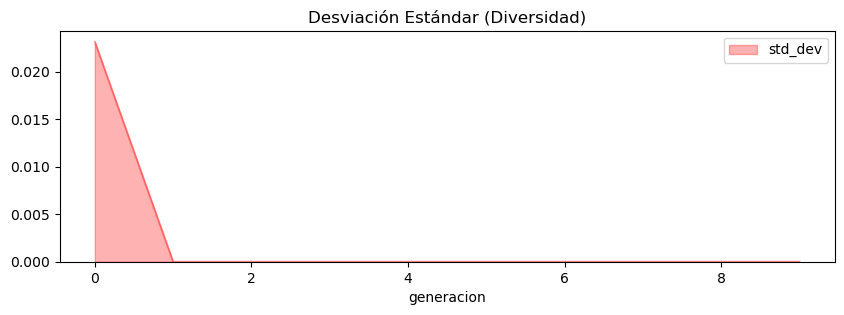

In [7]:
# Usando un área rellena para ver la pérdida de diversidad
results_log.plot(x="generacion", y="std_dev", kind="area", 
                color="red", alpha=0.3, figsize=(10, 3),
                title="Desviación Estándar (Diversidad)")